# Project 1 – Reservoir Data Analysis
Project links:
- GitHub repository: [IND320 GitHub repository](https://github.com/newrybalas/IND320)
- Streamlit application: [Reservoir Streamlit app](https://ind320-project1.streamlit.app/)
- Video link: [IND320 - Newry](https://nmbu.cloud.panopto.eu/Panopto/Pages/Viewer.aspx?id=2d82e29a-5d43-4ea4-97c8-b4d40130f077)

This notebook imports and explores reservoir data from `reservoirs.csv`.
The dataset is cleaned and visualized using Pandas and Matplotlib.

In [ ]:
# Import libraries used for data analysis and plotting
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read the reservoir data from the CSV file
df = pd.read_csv("reservoirs.csv")

In [3]:
# Display the first five rows of the dataset
df.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [4]:
# Display the column names
df.columns

Index(['dato_Id', 'omrType', 'omrnr', 'iso_aar', 'iso_uke', 'fyllingsgrad',
       'kapasitet_TWh', 'fylling_TWh', 'neste_Publiseringsdato',
       'fyllingsgrad_forrige_uke', 'endring_fyllingsgrad'],
      dtype='object')

In [5]:
# Rename the columns from Norwgian to English
df = df.rename(columns={
    "dato_Id": "date_Id",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "fill_level",
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "fill_TWh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "fill_level_previous_week",
    "endring_fyllingsgrad": "change_in_fill_level"})

In [6]:
# Display the dataset after renaming the columns
df.columns

Index(['date_Id', 'area_type', 'area_number', 'iso_year', 'iso_week',
       'fill_level', 'capacity_TWh', 'fill_TWh', 'next_publication_date',
       'fill_level_previous_week', 'change_in_fill_level'],
      dtype='object')

In [7]:
# Check the number of rows and columns in the dataset
df.shape

(14877, 11)

In [8]:
# Check information about the dataset
df.dtypes

date_Id                      object
area_type                    object
area_number                   int64
iso_year                      int64
iso_week                      int64
fill_level                  float64
capacity_TWh                float64
fill_TWh                    float64
next_publication_date        object
fill_level_previous_week    float64
change_in_fill_level        float64
dtype: object

# Plotting each column separately:

In [9]:
df.head()

,date_Id,area_type,area_number,iso_year,iso_week,fill_level,capacity_TWh,fill_TWh,next_publication_date,fill_level_previous_week,change_in_fill_level
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [10]:
# Convert the date column to datetime format
df["date_Id"] = pd.to_datetime(df["date_Id"])

In [ ]:
# Check the new datetime column about the dataset
df["date_Id"].head()

0   1995-09-03
1   2020-11-15
2   2011-08-28
3   1998-07-05
4   2011-03-27
Name: date_Id, dtype: datetime64[ns]

In [12]:
import matplotlib.pyplot as plt

In [13]:
# Sort the dataset by date
df_sorted = df.sort_values("date_Id")

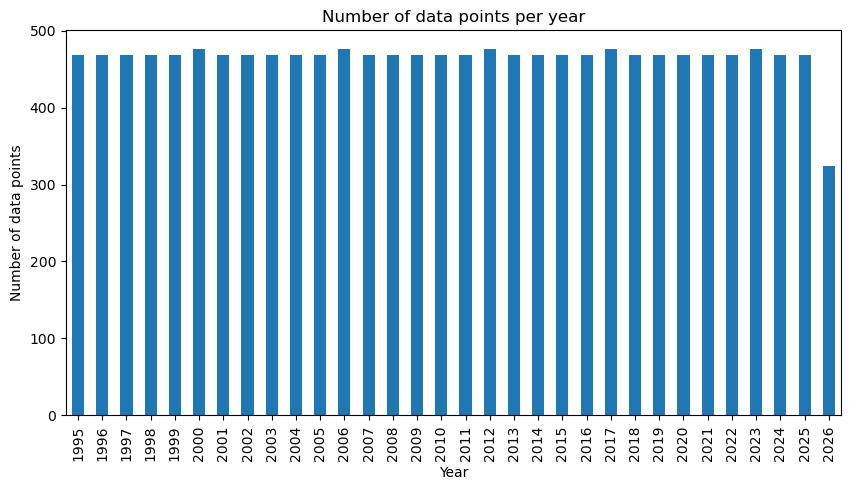

In [ ]:
# Column - date_Id
# Plot the number of data points for each year
plt.figure(figsize=(10, 5))

# Count and plot the number of observations per year
df_sorted["date_Id"].dt.year.value_counts().sort_index().plot(kind="bar")

# Name the plot and axes
plt.title("Number of data points per year")
plt.xlabel("Year")
plt.ylabel("Number of data points")

plt.show()

In [15]:
# Check the number of unique area types and display them
print("Number of area types:", df["area_type"].nunique())
print("Area types:", df["area_type"].unique())

Number of area types: 3
Area types: ['EL' 'NO' 'VASS']


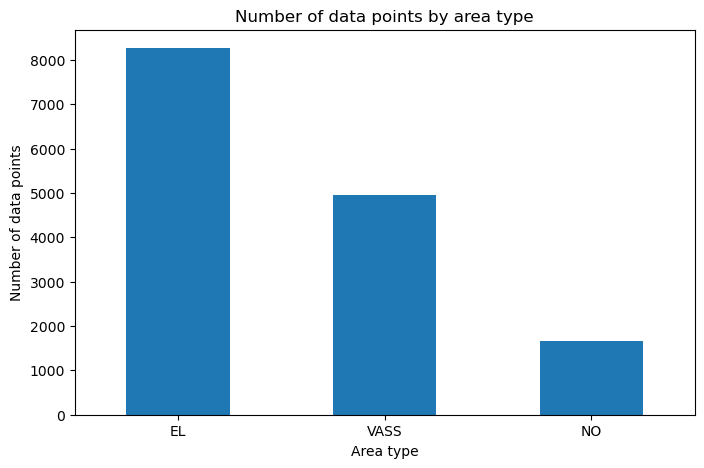

In [ ]:
# Column - area_type
plt.figure(figsize=(8, 5))

# Count and plot the number of observations for each area type
df["area_type"].value_counts().plot(kind="bar")

plt.title("Number of data points by area type")
plt.xlabel("Area type")
plt.ylabel("Number of data points")

plt.xticks(rotation=0)

plt.show()

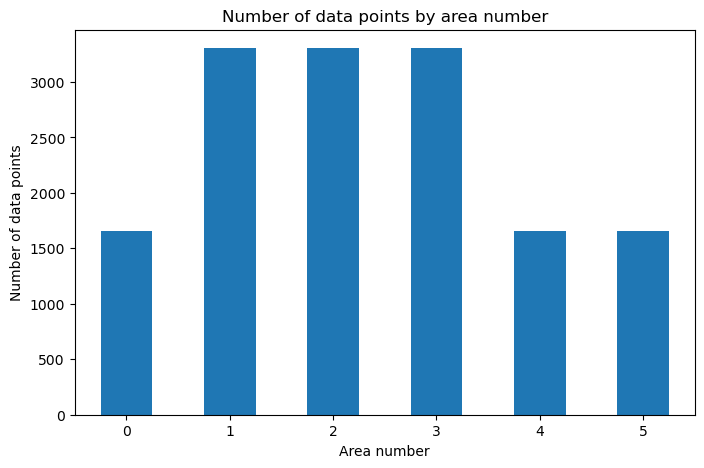

In [ ]:
# Column - area_number
plt.figure(figsize=(8, 5))

# Count and plot the number of observations for each area number
df["area_number"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of data points by area number")
plt.xlabel("Area number")
plt.ylabel("Number of data points")

plt.xticks(rotation=0)

plt.show()

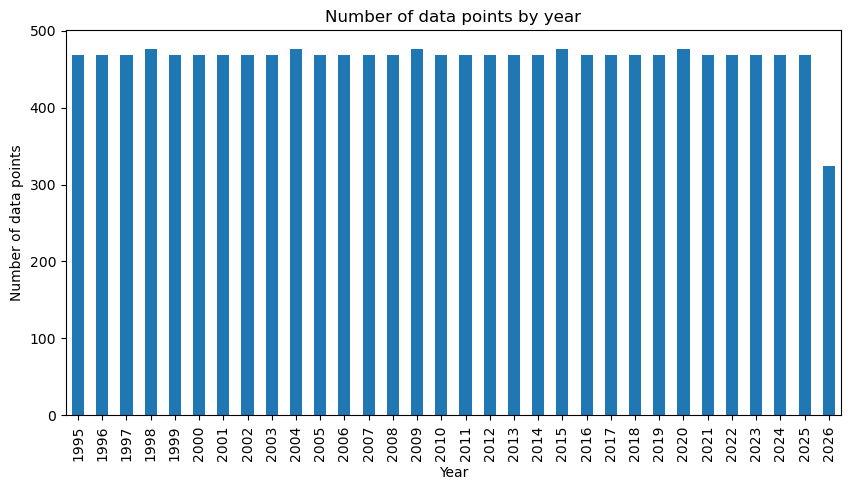

In [ ]:
# Column - iso_year
# This gives the same yearly distribution as date_Id because iso_year is based on the date 
plt.figure(figsize=(10, 5))

# Count and plot the number of data points for each year
df["iso_year"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of data points by year")
plt.xlabel("Year")
plt.ylabel("Number of data points")

plt.show()

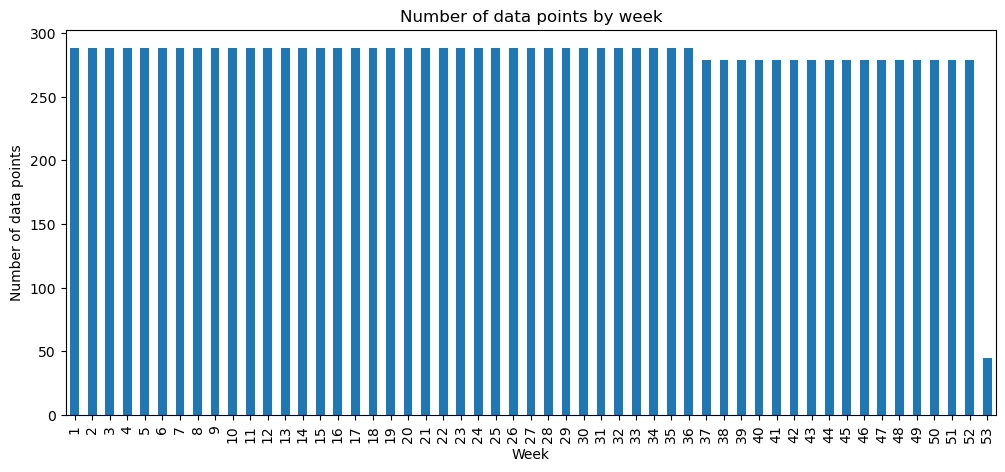

In [ ]:
# Column - iso_week
plt.figure(figsize=(12, 5))

# Count and plot the number of data points for each week
df["iso_week"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of data points by week")
plt.xlabel("Week")
plt.ylabel("Number of data points")

plt.show()

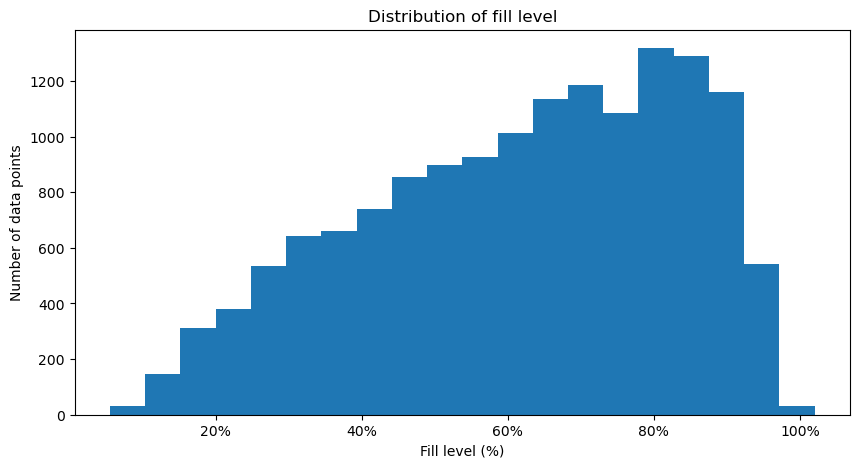

In [ ]:
# Column - fill_level
# Plot the distribution of fill level 
plt.figure(figsize=(10, 5))

# The histogram divides the fill level values into 20 intervals and shows how many observations are in each interval.
plt.hist(df["fill_level"], bins=20)

plt.title("Distribution of fill level")
plt.xlabel("Fill level (%)")
plt.ylabel("Number of data points")

from matplotlib.ticker import PercentFormatter
# Display fill level as percentage 
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))

plt.show()

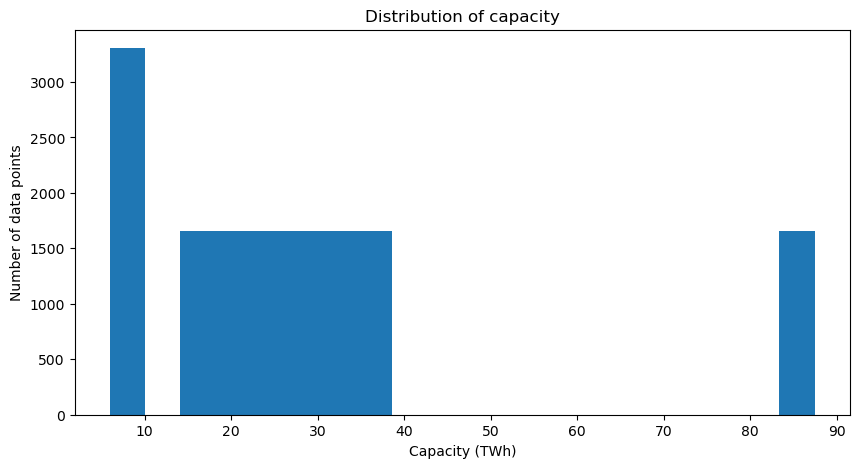

In [ ]:
# Column - capacity_TWh
# Plot the distribution of reservoir capacity
plt.figure(figsize=(10, 5))

# The histogram divides the capacity values into 20 intervals and shows how many observations are in each interval.
plt.hist(df["capacity_TWh"], bins=20)

plt.title("Distribution of capacity")
plt.xlabel("Capacity (TWh)")
plt.ylabel("Number of data points")

plt.show()

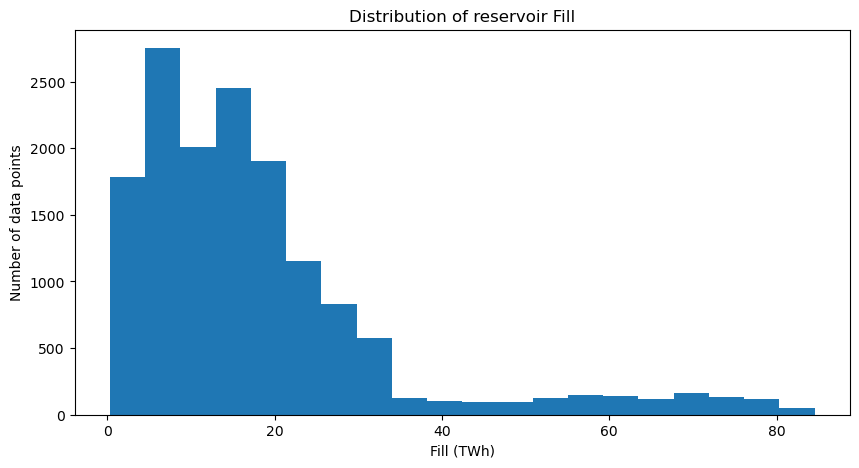

In [ ]:
# Column - fill_TWh
# Plot the distribution of reservoir fill
plt.figure(figsize=(10, 5))

# The histogram divides the fill TWh values into 20 intervals and shows how many observations are in each interval.
plt.hist(df["fill_TWh"], bins=20)

plt.title("Distribution of reservoir Fill")
plt.xlabel("Fill (TWh)")
plt.ylabel("Number of data points")

plt.show()

In [23]:
# Check which years contain unregistered publication dates
df.groupby(df["date_Id"].dt.year)["next_publication_date"].apply(
    lambda x: (x != "0001-01-01T00:00:00").sum()
)

date_Id
1995      0
1996      0
1997      0
1998      0
1999      0
2000      0
2001      0
2002      0
2003      0
2004      0
2005      0
2006      0
2007      0
2008      0
2009      0
2010      0
2011      0
2012      0
2013      0
2014      0
2015      0
2016      0
2017      0
2018      0
2019    414
2020    468
2021    468
2022    468
2023    477
2024    468
2025    468
2026    324
Name: next_publication_date, dtype: int64

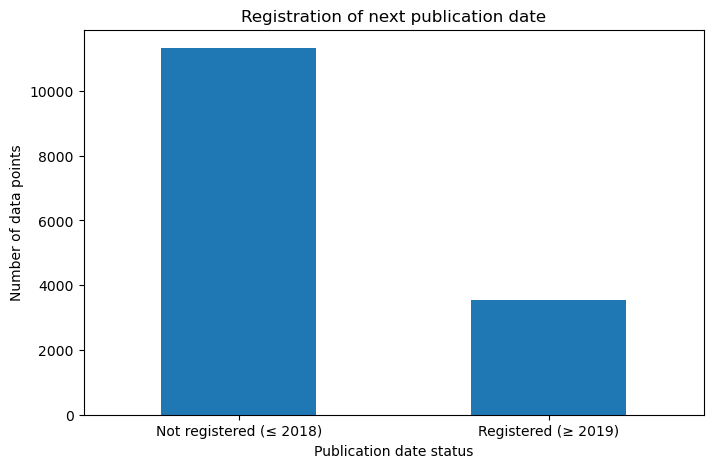

In [ ]:
# Classify whether the next publication date is registered
publication_status = df["next_publication_date"].apply(
    lambda x: "Not registered (≤ 2018)" if x == "0001-01-01T00:00:00" else "Registered (≥ 2019)"
)

# Column - next_publication_date
# Plot the number of registered and unregistered publication dates
plt.figure(figsize=(8, 5))

# Count each publication status and display it as a bar chart
publication_status.value_counts().plot(kind="bar")

plt.title("Registration of next publication date")
plt.xlabel("Publication date status")
plt.ylabel("Number of data points")

plt.xticks(rotation=0)

plt.show()

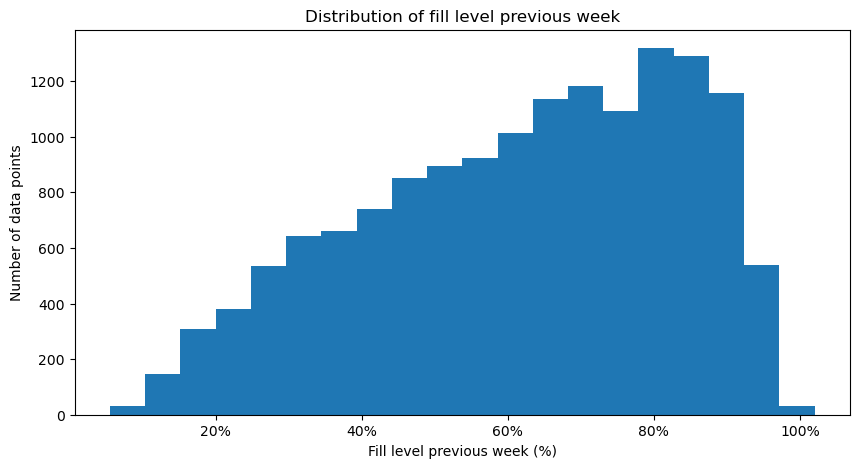

In [ ]:
# Column - fill_level_previous_week
# Plot the distribution of fill level from the previous week
plt.figure(figsize=(10, 5))

# Show the distribution of the previous week's fill level using 20 intervals
plt.hist(df["fill_level_previous_week"], bins=20)

plt.title("Distribution of fill level previous week")
plt.xlabel("Fill level previous week (%)")
plt.ylabel("Number of data points")

# Display fill level as percentage 
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))

plt.show()

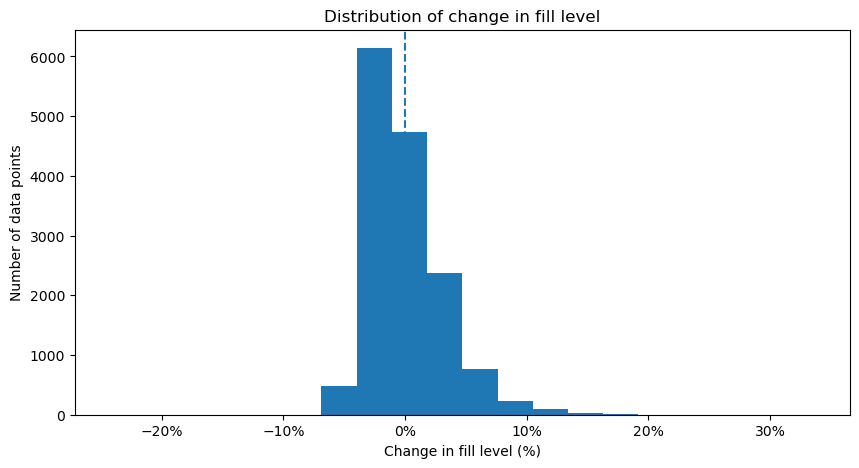

In [ ]:
# Column - change_in_fill_level
# Plot the distribution of change in fill level
plt.figure(figsize=(10, 5))

# Show the distribution of the previous week's fill level using 20 intervals
plt.hist(df["change_in_fill_level"], bins=20)

# Add a line at zero to separate negative and positive changes
plt.axvline(0, linestyle="--")

plt.title("Distribution of change in fill level")
plt.xlabel("Change in fill level (%)")
plt.ylabel("Number of data points")

# Display change in fill level as percentage 
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))

plt.show()

# Plotting all columns together:
Select only numerical columns that are relevant for the plots because the scales are different. 

The columns `iso_year`, `iso_week`, and `next_publication_date` are excluded from the combined plot. These are already represented by `date_Id`, while `next_publication_date` contains many unregistered values and describes publication information rather than reservoir measurements.

`capacity_TWh` and `fill_TWh` are excluded because the relative reservoir fill is already represented by `fill_level`, making them less useful in the combined plot.

`area_type` and `area_number` are excluded because they represent area classifications rather than measurements over time.

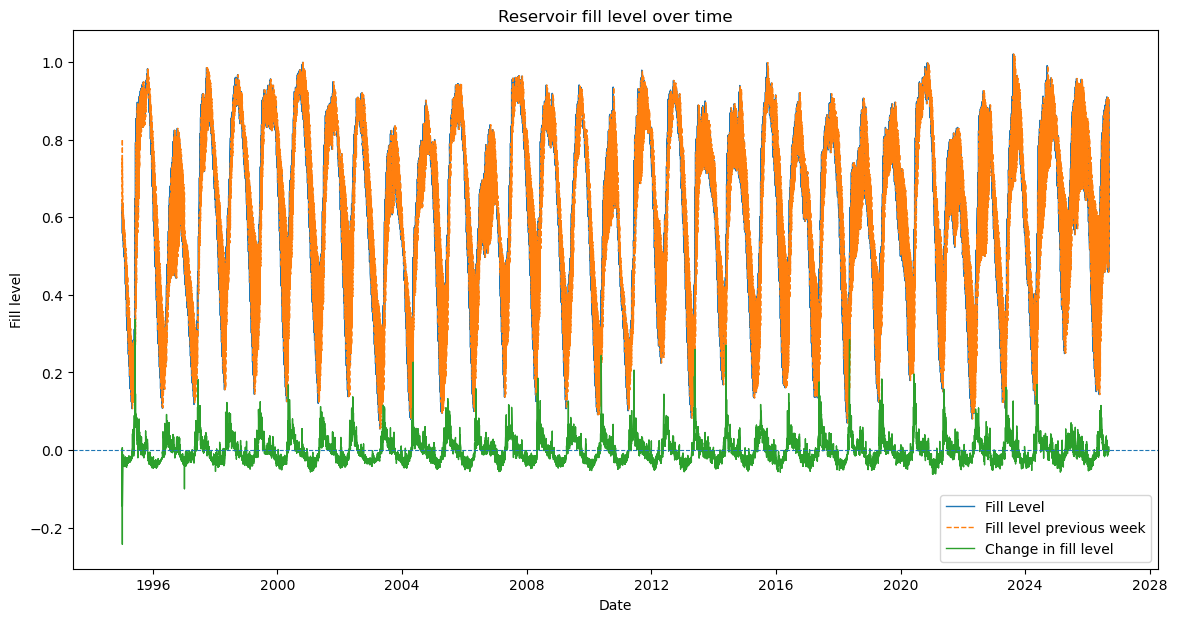

In [ ]:
# Create the figure
plt.figure(figsize=(14, 7))

# Plot the fill level over time
plt.plot(
    df_sorted["date_Id"],
    df_sorted["fill_level"],
    label="Fill Level",
    linewidth=1
)

# Plot the previous week's fill level
plt.plot(
    df_sorted["date_Id"],
    df_sorted["fill_level_previous_week"],
    label="Fill level previous week",
    linestyle="--",
    linewidth=1
)

# Plot the change in fill level
plt.plot(
    df_sorted["date_Id"],
    df_sorted["change_in_fill_level"],
    label="Change in fill level",
    linewidth=1
)

# Add a line at zero to separate negative and positive changes
plt.axhline(0, linestyle="--", linewidth=0.8)

# Add title and axis labels
plt.title("Reservoir fill level over time")
plt.xlabel("Date")
plt.ylabel("Fill level")
plt.legend()

# Display the plot
plt.show()

# Evaluation of the initial combined plot
`fill_level_previous_week` follows almost the same pattern as `fill_level`. 
It is therefore excluded from the final combined plot to avoid redundant information. Another reason is that the difference in fill level is already represented by `change_in_fill_level`.

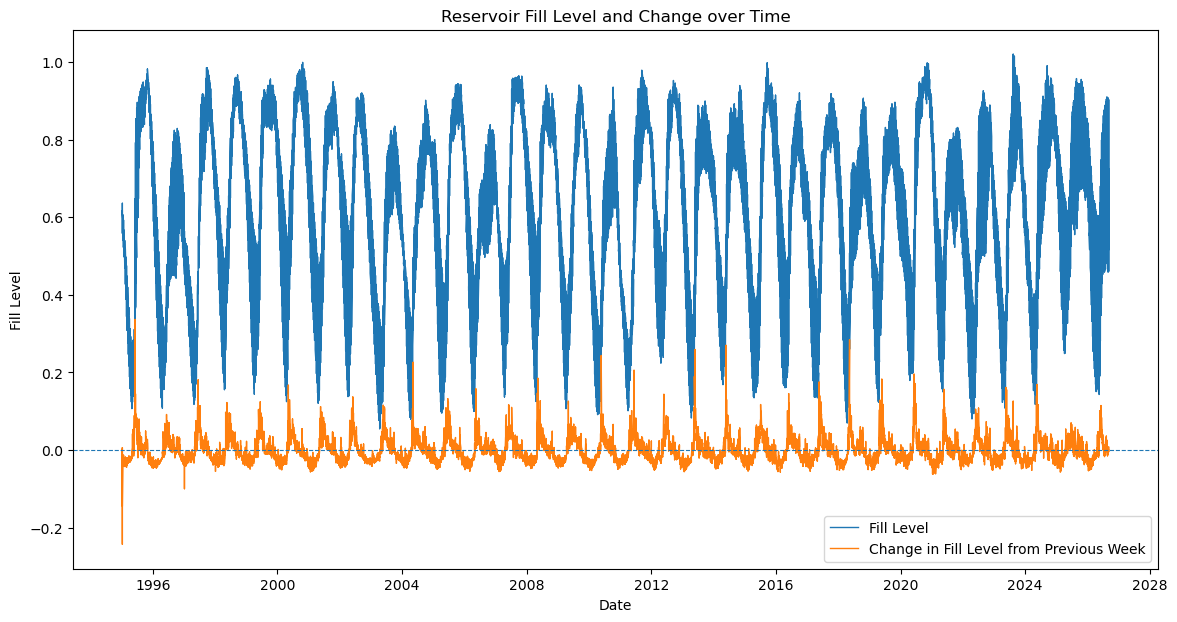

In [28]:
plt.figure(figsize=(14, 7))

plt.plot(
    df_sorted["date_Id"],
    df_sorted["fill_level"],
    label="Fill Level",
    linewidth=1
)

plt.plot(
    df_sorted["date_Id"],
    df_sorted["change_in_fill_level"],
    label="Change in Fill Level from Previous Week",
    linewidth=1
)

plt.axhline(0, linestyle="--", linewidth=0.8)

plt.title("Reservoir Fill Level and Change over Time")
plt.xlabel("Date")
plt.ylabel("Fill Level")
plt.legend()

plt.show()

# Reflection 

The initial plot contains multiple observations for the same date, which makes the lines difficult to interpret. 
To make the overall development clearer, the data is grouped by date and the average values are calculated for each date.

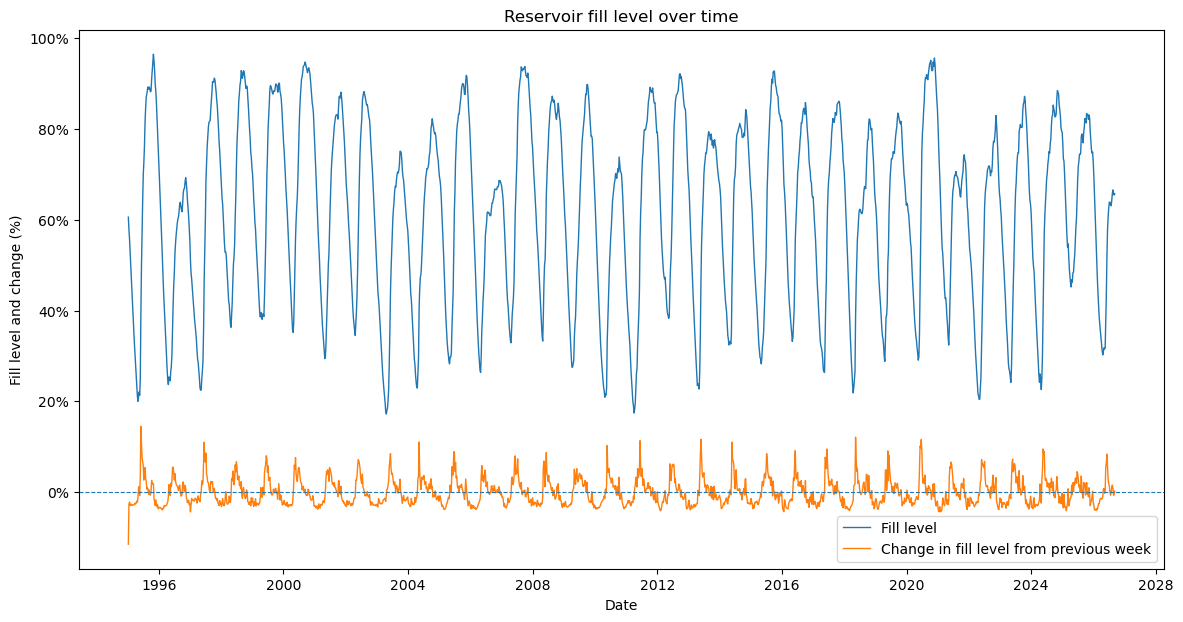

In [29]:
from matplotlib.ticker import PercentFormatter

# Calculate the average values for each date
plot_data = (
    df_sorted
    .groupby("date_Id")[["fill_level", "change_in_fill_level"]]
    .mean()
    .reset_index()
)

# Create the plot
plt.figure(figsize=(14, 7))

plt.plot(
    plot_data["date_Id"],
    plot_data["fill_level"],
    label="Fill level",
    linewidth=1
)

plt.plot(
    plot_data["date_Id"],
    plot_data["change_in_fill_level"],
    label="Change in fill level from previous week",
    linewidth=1
)

# Add a horizontal line at 0
plt.axhline(0, linestyle="--", linewidth=0.8)

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.title("Reservoir fill level over time")
plt.xlabel("Date")
plt.ylabel("Fill level and change (%)")
plt.legend()

plt.show()

# Use of AI
I used ChatGPT as a support tool throughout the project. It was mainly used to help me understand Python, Pandas, Matplotlib, Streamlit and GitHub. I also used AI to explain error messages, suggest code, and help me understand how different parts of the code work. I tested and adjusted the suggested code myself to make sure it worked with my data and project. 

# Project log

In this project, I worked with reservoir data using Jupyter Notebook and Streamlit. I had little previous experience with these tools, so a large part of the project was learning how they work and how Python can be used to work with data.

The next part was to create plots for the different columns in the dataset. I used Matplotlib to create different types of plots depending on the type of data. This helped me understand the differences between the variables and how they could be presented. I also created a plot with several columns together. I found that this was more difficult because the dataset contains several observations for the same date and the variables have different scales. I therefore had to think about which variables made sense to compare and how the data should be presented.

After working with the data in Jupyter Notebook, I created a Streamlit application. This was my first experience with Streamlit. I created a multipage application with a home page and separate pages for the data table and plots. In the data table page, I displayed the reservoir data and used LineChartColumn to show the numerical data from the first month. In the plot page, I added a dropdown menu where the user can select a column and a slider where the user can select a range of months. 

I also learned how to use Git and GitHub during the project. I uploaded the Streamlit files to a GitHub repository. For later updates, I used GitHub Desktop to commit and push the changes. Finally, I connected the GitHub repository to Streamlit Community Cloud and published the application online.

Overall, the project gave me practical experience with Jupyter Notebook, Pandas, Matplotlib, Streamlit and GitHub. The most challenging parts were understanding errors and getting the different tools to work together. By testing the code and fixing problems step by step, I gained a better understanding of the complete process from reading data to publishing an interactive application.